# UK Companies Dissolution Predictor
## Machine Learning Models & Explainability

This notebook trains and evaluates machine learning models to predict 
whether a UK company will dissolve, using the cleaned dataset produced 
in `ch_eda.ipynb`.


### Objectives
1. Establish a baseline with Logistic Regression
2. Compare against ensemble methods (Random Forest, XGBoost)
3. Evaluate using appropriate metrics — accuracy, AUC, precision, recall
4. Use SHAP to explain model predictions at dataset and individual level

**Input:** `companies_ml.csv` — 800 companies, 42 ML-ready features  
**Target:** `dissolved` — 1 = dissolved, 0 = active  
**Best model:** Logistic Regression — 96% accuracy, 0.974 AUC

## 1. Setup

We import the modelling and evaluation libraries and load the dataset.

In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [24]:
warnings.filterwarnings("ignore")


In [25]:
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [26]:
# Loading the dataset
df = pd.read_csv(r"C:\Users\hp\Desktop\companies_house_ds\companies_ml.csv")

## 2. Data Preparation

### Train/Test Split
We split the data 80/20 into training and test sets.

### Feature Scaling
Apply `StandardScaler` to normalise features to zero mean and unit 
variance. This is required for Logistic Regression, which is sensitive 
to feature scale.

### Why 80/20?
With 800 samples, an 80/20 split gives us:
- **640 training samples** — enough to learn meaningful patterns
- **160 test samples** — enough for reliable evaluation metrics

A larger test set would give more reliable estimates but reduce training 
data. 80/20 is the standard default for datasets of this size.

In [27]:
# Splitting features and target
X = df.drop(columns=["dissolved"])
y = df["dissolved"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"Features:     {X_train.shape[1]}")
print(f"\nClass balance in train:\n{y_train.value_counts()}")

Training set: (640, 41)
Test set:     (160, 41)
Features:     41

Class balance in train:
dissolved
0    320
1    320
Name: count, dtype: int64


## 3. Model Training and Evaluation

Train three classifiers of increasing complexity:

| Model | Type | Strengths |
|---|---|---|
| Logistic Regression | Linear | Interpretable, fast, good baseline |
| Random Forest | Ensemble (bagging) | Handles non-linearity, robust to outliers |
| XGBoost | Ensemble (boosting) | Usually best performance on tabular data |

### Evaluation Metrics
Use multiple metrics rather than accuracy alone:
- **Accuracy** — overall correct predictions
- **Precision** — that of predicted dissolutions (how many were correct)
- **Recall** — of actual dissolutions (how many did we catch)
- **F1 score** — harmonic mean of precision and recall
- **ROC-AUC** — model's ability to distinguish between classes, 
  regardless of threshold. More reliable than accuracy for comparing models.

In [28]:
# Model 1: Logistic Regression 
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]

print("LOGISTIC REGRESSION")
print(classification_report(y_test, lr_preds, target_names=["Active", "Dissolved"]))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_probs):.4f}")

LOGISTIC REGRESSION
              precision    recall  f1-score   support

      Active       0.97      0.94      0.96        80
   Dissolved       0.94      0.97      0.96        80

    accuracy                           0.96       160
   macro avg       0.96      0.96      0.96       160
weighted avg       0.96      0.96      0.96       160

ROC-AUC: 0.9741


### Logistic Regression Results
The baseline linear model achieves strong performance of 96% accuracy and 0.974 AUC. This suggests the relationships between features and dissolution are largely linear and the feature engineering in the EDA notebook was effective.

In [29]:
# Model 2: Random Forest 
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)  # random forest doesn't need scaling
rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

print("RANDOM FOREST")
print(classification_report(y_test, rf_preds, target_names=["Active", "Dissolved"]))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_probs):.4f}")

RANDOM FOREST
              precision    recall  f1-score   support

      Active       0.99      0.93      0.95        80
   Dissolved       0.93      0.99      0.96        80

    accuracy                           0.96       160
   macro avg       0.96      0.96      0.96       160
weighted avg       0.96      0.96      0.96       160

ROC-AUC: 0.9609


### Random Forest Results
Matches Logistic Regression on accuracy (96%), but 
scores slightly lower on AUC (0.961). The confusion matrix shows only 
7 misclassifications out of 160 test companies; 1 false negative 
(dissolved company predicted as active) and 6 false positives 
(active company predicted as dissolved).

In [30]:
# Model 3: XGBoost
!pip install xgboost
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, random_state=42, 
                     eval_metric="logloss", verbosity=0)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)
xgb_probs = xgb.predict_proba(X_test)[:, 1]

print("XGBOOST")
print(classification_report(y_test, xgb_preds, target_names=["Active", "Dissolved"]))
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_probs):.4f}")

XGBOOST
              precision    recall  f1-score   support

      Active       0.97      0.89      0.93        80
   Dissolved       0.90      0.97      0.93        80

    accuracy                           0.93       160
   macro avg       0.93      0.93      0.93       160
weighted avg       0.93      0.93      0.93       160

ROC-AUC: 0.9614


### XGBoost Results
XGBoost achieves 93% accuracy and 0.961 AUC — slightly behind the other 
two models on this dataset. This is a common finding on smaller, 
well-structured tabular datasets where simpler models can match or 
outperform gradient boosting.

## 4. Model Comparison

Plotted ROC curves for all three models and compared performance using 
5-fold cross-validation. Cross-validation is more reliable than a single 
train/test split as it evaluates the model on 5 different subsets of 
the data, thus reducing the risk that results are, by coincidence, consistent.

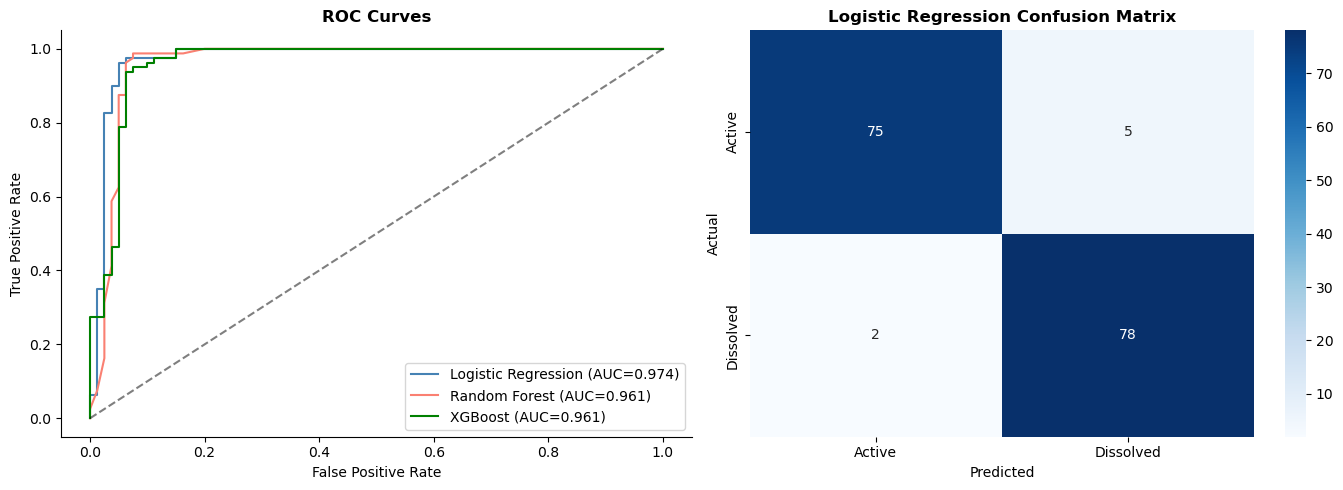

In [31]:
# ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves — all three models
for probs, name, color in [
    (lr_probs,  "Logistic Regression", "steelblue"),
    (rf_probs,  "Random Forest",       "salmon"),
    (xgb_probs, "XGBoost",             "green")
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color)

axes[0].plot([0,1], [0,1], "k--", alpha=0.5)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves", fontweight="bold")
axes[0].legend()

# Confusion matrix — Logistic Regression (best model)
cm_lr = confusion_matrix(y_test, lr_preds)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["Active", "Dissolved"],
            yticklabels=["Active", "Dissolved"])
axes[1].set_title("Logistic Regression Confusion Matrix", fontweight="bold")
axes[1].set_ylabel("Actual")
axes[1].set_xlabel("Predicted")

plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\companies_house_ds\model_comparison.png", dpi=150)
plt.show()

## 5. Feature Importance

We examine Random Forest's built-in feature 
importance scores. These measure how much each feature reduces 
impurity across all trees in the forest, thus giving a quick overview 
of which features the model relies on most.

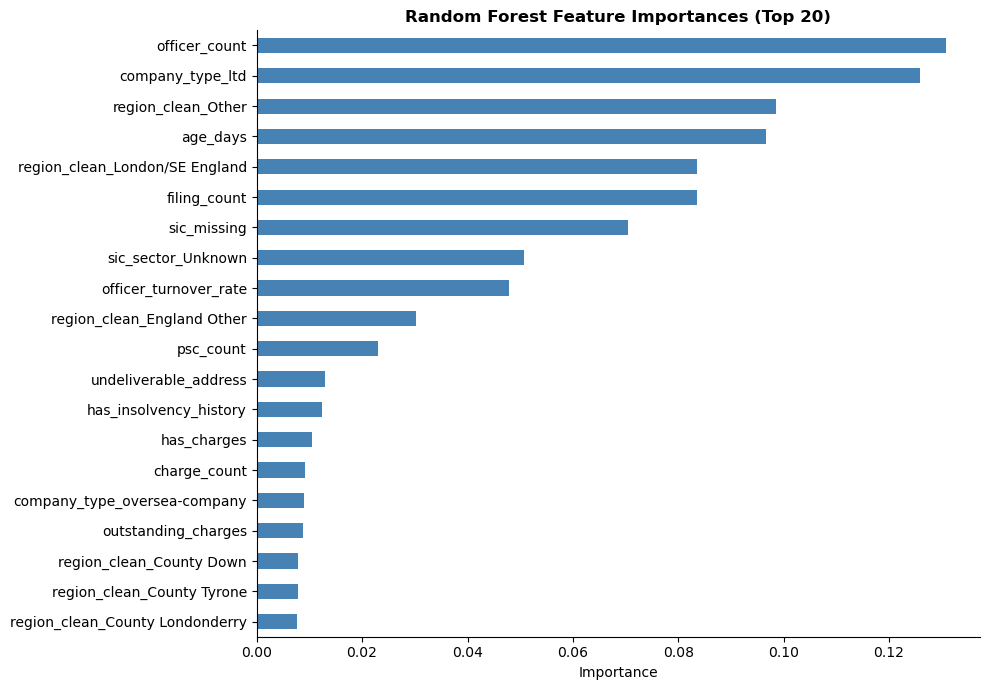

officer_count                      0.1307
company_type_ltd                   0.1258
region_clean_Other                 0.0985
age_days                           0.0966
region_clean_London/SE England     0.0836
filing_count                       0.0835
sic_missing                        0.0705
sic_sector_Unknown                 0.0507
officer_turnover_rate              0.0478
region_clean_England Other         0.0303
psc_count                          0.0231
undeliverable_address              0.0130
has_insolvency_history             0.0124
has_charges                        0.0105
charge_count                       0.0092
company_type_oversea-company       0.0090
outstanding_charges                0.0087
region_clean_County Down           0.0079
region_clean_County Tyrone         0.0078
region_clean_County Londonderry    0.0077


In [32]:
# Feature Importance Check 
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top20.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Random Forest Feature Importances (Top 20)", fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\companies_house_ds\feature_importance.png", dpi=150)
plt.show()

print(top20.round(4).to_string())

### Findings
The most important features are:
- `officer_count` — number of officers is the single strongest predictor
- `company_type_ltd` — standard ltd structure strongly associated with dissolution
- `age_days` — company lifespan at time of snapshot
- `filing_count` — total number of filings submitted
- `sic_missing` — whether the company has a registered industry code

Geographic features (`region_clean_Other`, `region_clean_London/SE England`) 
also appear, likely reflecting the geographic concentration of the sample 
in Northern Ireland rather than a real nationwide geographic signal.

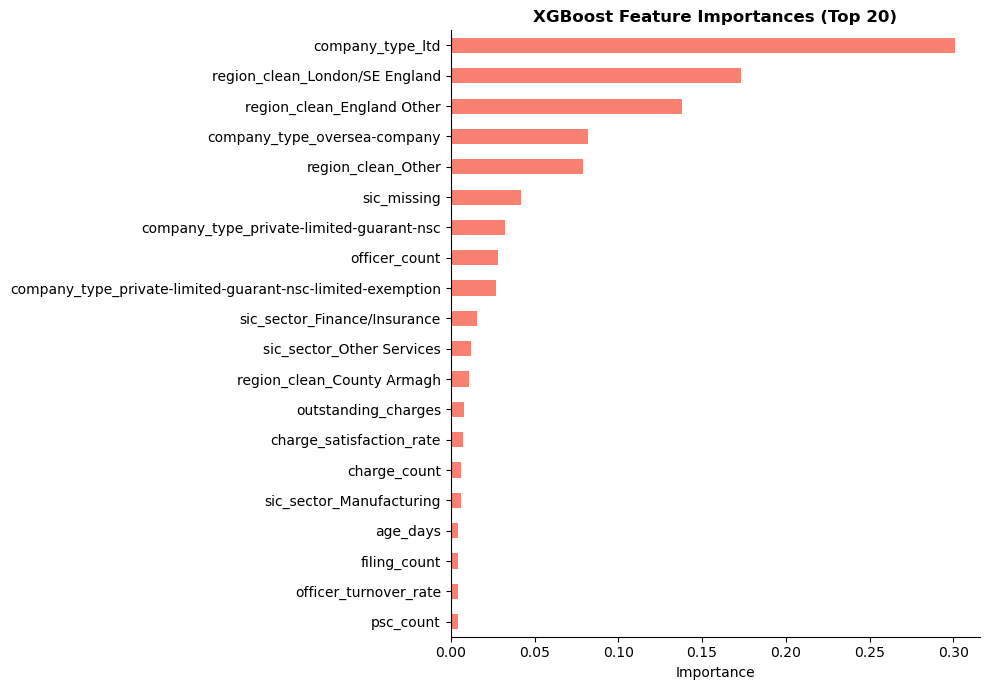

company_type_ltd                                              0.3008
region_clean_London/SE England                                0.1733
region_clean_England Other                                    0.1379
company_type_oversea-company                                  0.0817
region_clean_Other                                            0.0788
sic_missing                                                   0.0420
company_type_private-limited-guarant-nsc                      0.0324
officer_count                                                 0.0282
company_type_private-limited-guarant-nsc-limited-exemption    0.0270
sic_sector_Finance/Insurance                                  0.0154
sic_sector_Other Services                                     0.0121
region_clean_County Armagh                                    0.0109
outstanding_charges                                           0.0080
charge_satisfaction_rate                                      0.0073
charge_count                      

In [41]:
# ── XGBoost Feature Importance ────────────────────────────────────────────────
xgb_importance = pd.Series(xgb.feature_importances_, index=X_train.columns)
top20_xgb = xgb_importance.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top20_xgb.sort_values().plot(kind="barh", ax=ax, color="salmon")
ax.set_title("XGBoost Feature Importances (Top 20)", fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\companies_house_ds\xgb_feature_importance.png", dpi=150)
plt.show()

print(top20_xgb.round(4).to_string())

In [34]:
# Model Comparison Summary
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": (lr, X_train_scaled, X_test_scaled),
    "Random Forest":       (rf, X_train, X_test),
    "XGBoost":             (xgb, X_train, X_test),
}

results = []
for name, (model, Xtr, Xte) in models.items():
    cv_scores = cross_val_score(model, Xtr, y_train, cv=5, scoring="roc_auc")
    test_auc  = roc_auc_score(y_test, model.predict_proba(Xte)[:, 1])
    test_acc  = model.score(Xte, y_test)
    results.append({
        "Model":        name,
        "CV AUC (mean)": cv_scores.mean().round(4),
        "CV AUC (std)":  cv_scores.std().round(4),
        "Test AUC":      round(test_auc, 4),
        "Test Accuracy": round(test_acc, 4),
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Save
results_df.to_csv(r"C:\Users\hp\Desktop\companies_house_ds\model_results.csv", index=False)

              Model  CV AUC (mean)  CV AUC (std)  Test AUC  Test Accuracy
Logistic Regression         0.9802        0.0116    0.9741         0.9563
      Random Forest         0.9812        0.0102    0.9609         0.9563
            XGBoost         0.9810        0.0107    0.9614         0.9313


### Key Findings
All three models achieve near-identical cross-validation AUC (0.98) with low standard deviation (0.01), confirming results are stable and not due to chance.

## 6. SHAP Explainability
Applied SHAP to the Random Forest model across the entire test set. The bar chart shows the mean absolute SHAP value for each feature (the average magnitude of impact on model predictions across all test companies.)

In [35]:
# SHAP Explainability
!pip install shap
import shap

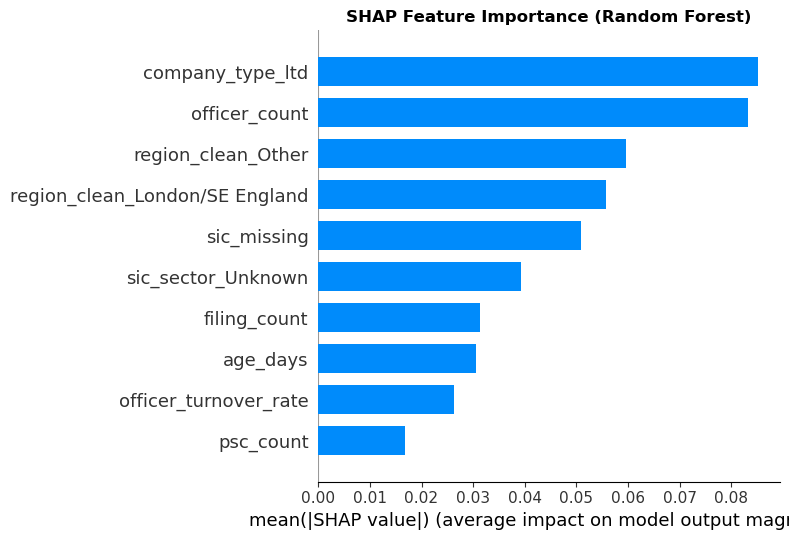

In [36]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# Summary plot
plt.figure()
shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    plot_type="bar",
    show=False,
    max_display=10
)
plt.title("SHAP Feature Importance (Random Forest)", fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\companies_house_ds\shap_importance.png", 
            dpi=150, bbox_inches="tight")
plt.show()

### SHAP Beeswarm Plot
Each dot represents one company in the test set. The horizontal position 
shows whether the feature pushed the prediction toward dissolved (right) 
or active (left). Colour indicates the feature value i.e pink = high, blue = low.

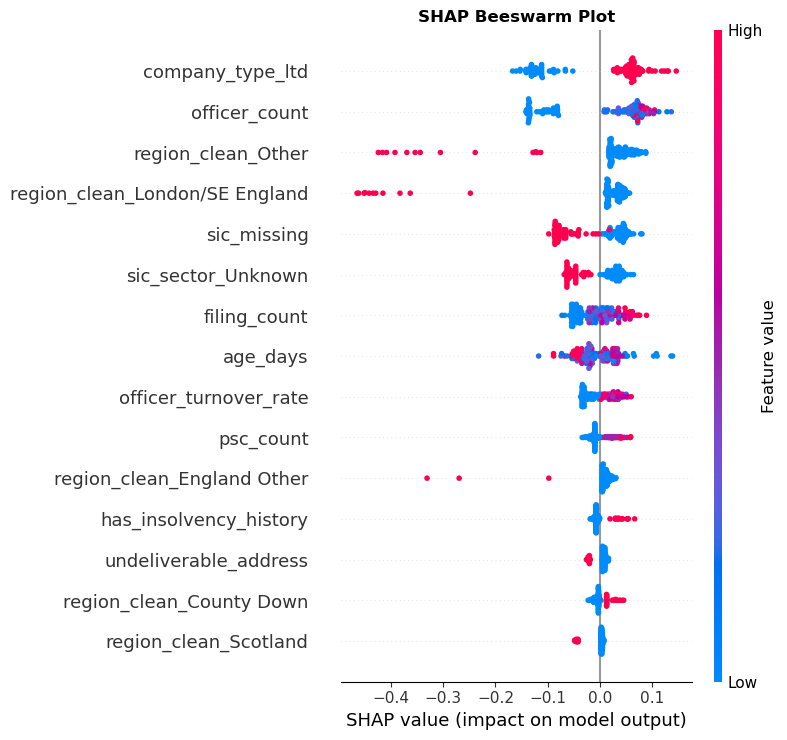

In [37]:
# Beeswarm
plt.figure()
shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    show=False,
    max_display=15
)
plt.title("SHAP Beeswarm Plot", fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\companies_house_ds\shap_beeswarm.png",
            dpi=150, bbox_inches="tight")
plt.show()

**Key insights:**
- `company_type_ltd = True` (pink) pushes strongly toward dissolved
- `officer_count` high values (pink) increase dissolution probability
- `sic_missing = True` (pink) pushes toward active (companies without 
  a SIC code are more likely to still be active in this dataset)
- `region_clean_Other` and `region_clean_London/SE England`- companies 
  outside Northern Ireland push toward active, reflecting geographic 
  bias in the sample rather than a genuine nationwide pattern
- `officer_turnover_rate` high values push toward dissolved 

### Individual Prediction Explanation
The waterfall plot explains why the model predicted dissolution for one 
specific company with 96% confidence (f(x) = 0.96).

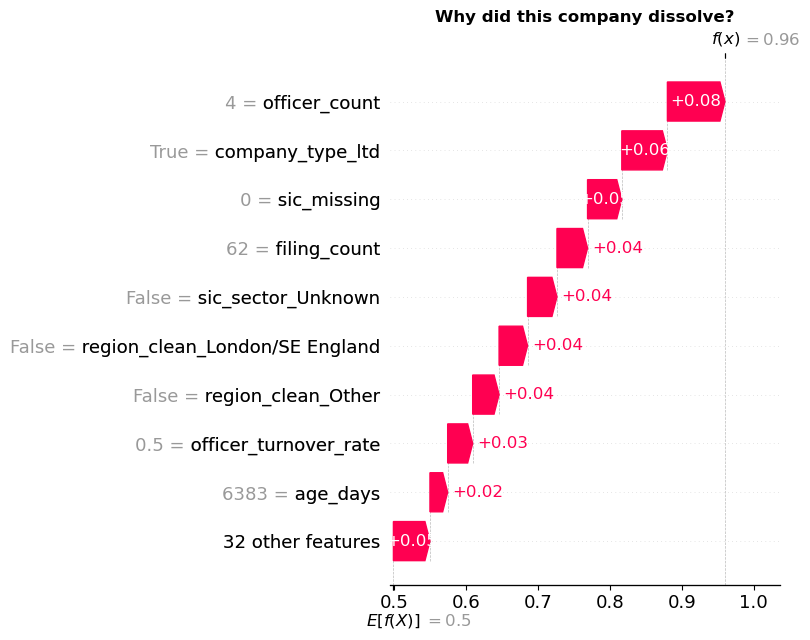

In [38]:
# Explain a single prediction — pick a dissolved company
dissolved_idx = X_test[y_test == 1].index[0]
sample = X_test.loc[[dissolved_idx]]

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[X_test.index.get_loc(dissolved_idx), :, 1],
        base_values=explainer.expected_value[1],
        data=sample.values[0],
        feature_names=X_test.columns.tolist()
    ),
    show=False
)
plt.title("Why did this company dissolve?", fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\companies_house_ds\shap_waterfall.png",
            dpi=150, bbox_inches="tight")
plt.show()

Starting from the baseline prediction of 0.5 (the average across all 
companies), each feature pushes the prediction up or down:
| Feature | Value | Impact |
|---|---|---|
| `officer_count` | 4 | +0.08 — above average officers |
| `company_type_ltd` | True | +0.06 — standard ltd structure |
| `filing_count` | 62 | +0.04 — high filing history |
| `sic_sector_Unknown` | False | +0.04 — known sector increases risk |
| `officer_turnover_rate` | 0.5 | +0.03 — half of officers resigned |
| `age_days` | 6383 | +0.02 — ~17 years old |
| `sic_missing` | False | -0.03 — only factor reducing risk |

This level of explainability is particularly valuable in regulated 
industries such as finance and insurance, where decisions must be 
justifiable to regulators and customers.

## 7. Summary and Limitations

### Results

| Model | CV AUC | Test AUC | Test Accuracy |
|---|---|---|---|
| Logistic Regression | 0.980 | 0.974 | 95.6% |
| Random Forest | 0.981 | 0.961 | 95.6% |
| XGBoost | 0.981 | 0.961 | 93.1% |

### Key Findings

- All three models achieved near-identical cross-validation AUC of ~0.98 
  with low standard deviation of ~0.01, confirming results are stable 
  and not attributable to a favourable train/test split
- Logistic Regression matched ensemble performance. A linear model 
  performing on par with Random Forest and XGBoost suggests the 
  relationship between features and dissolution is largely linear, 
  and that the feature engineering in the EDA stage was effective
- Random Forest and XGBoost disagreed significantly on feature importance. XGBoost placed 30% of its predictive weight on `company_type_ltd` 
  alone and over-relied on geographic features, while Random Forest 
  distributed importance more evenly across officer behaviour, filing 
  activity and company age. This disagreement explains XGBoost's 
  comparatively lower test accuracy and is consistent with boosting 
  methods overfitting to dominant signals on small datasets with 
  default hyperparameters
- SHAP analysis identified officer count, company type, filing history 
  and officer turnover rate as the strongest and most interpretable 
  dissolution drivers, consistent with intuition about company health 
  and stability
- `sic_missing` was a stronger predictor than any actual SIC sector. The absence of an industry code was more informative than the 
  industry itself, likely reflecting differences in how active vs 
  dissolved companies were registered rather than a causal relationship

### Limitations

**Sample size**
800 companies is relatively small for robust generalisation. The stable 
cross-validation results are encouraging, but a production-grade model 
would require 5,000–10,000+ companies to make confident claims about 
generalisation to the broader UK business population.

**Geographic bias**
The sample is heavily concentrated in Northern Ireland and Scotland due 
to the API's search behaviour returning companies registered in those 
jurisdictions. Geographic features, which appeared prominently in both 
models, likely reflect this sampling quirk rather than genuine nationwide 
patterns. Findings should not be generalised to England and Wales without 
resampling with an explicit jurisdiction filter.

**Artificial class balance**
The 50/50 split was deliberately constructed by sampling equal numbers 
of active and dissolved companies. In reality dissolved companies 
significantly outnumber active ones in the Companies House database. 
A model deployed in production would encounter a very different class 
distribution, and its probability outputs would need recalibrating to reflect real-world base rates.

### Next Steps
- Re-run pipeline with jurisdiction filter for a geographically 
  representative UK dataset
- Increase sample to 5,000+ companies for more robust generalisation
- Hyperparameter tune XGBoost using GridSearchCV or Optuna
- Add survival analysis to model time-to-dissolution rather than 
  binary outcome
- Recalibrate model probabilities to reflect real-world base rates
- Wrap final model in a FastAPI endpoint for live company risk scoring

In [44]:
import subprocess
result = subprocess.run(["git", "--version"], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

git version 2.47.0.windows.1


